<a href="https://colab.research.google.com/github/sevval-345/CNN/blob/main/Mask_R_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision --quiet

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


In [2]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def mask_rcnn_olustur(num_classes):
    """
    COCO veri setiyle önceden eğitilmiş (pretrained) Mask R-CNN modelini yükler
    ve son katmanlarını kendi sınıf sayımıza göre değiştirir (transfer learning).

    num_classes: arkaplan dahil toplam sınıf sayısı (örn. 2 = arkaplan + 1 nesne sınıfı)
    """
    # weights="DEFAULT": ImageNet/COCO üzerinde önceden eğitilmiş ağırlıkları indirir
    # Bu sayede sıfırdan eğitmek yerine, öğrenilmiş genel görsel özelliklerden faydalanırız
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")

    # --- 1. Sınıflandırma + Kutu Regresyon Başlığını Değiştir ---
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # --- 2. Maske Başlığını Değiştir ---
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )

    return model

In [4]:
# Örnek: arkaplan + 2 nesne sınıfı (toplam 3 sınıf) için model oluşturuyoruz
NUM_CLASSES = 3  # örn: 0=arkaplan, 1=kedi, 2=köpek
model_maskrcnn = mask_rcnn_olustur(NUM_CLASSES).to(device)
model_maskrcnn.eval()  # Değerlendirme (inference) moduna al

print("Mask R-CNN modeli başarıyla oluşturuldu.")
print(f"Toplam parametre sayısı: {sum(p.numel() for p in model_maskrcnn.parameters()):,}")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 193MB/s]


Mask R-CNN modeli başarıyla oluşturuldu.
Toplam parametre sayısı: 43,927,777


In [5]:
# Mask R-CNN, girdi olarak [0,1] aralığında normalize edilmiş RGB görüntü listesi bekler
# (sabit boyut şartı yoktur, model içeride kendi ölçekler)

sahte_goruntu_listesi = [torch.rand(3, 300, 400).to(device)]  # 1 adet sahte RGB görüntü

with torch.no_grad():
    tahminler = model_maskrcnn(sahte_goruntu_listesi)

# Model her görüntü için bir sözlük (dict) döndürür:
# 'boxes'  -> tespit edilen her nesnenin sınırlayıcı kutu koordinatları [x1,y1,x2,y2]
# 'labels' -> her kutunun tahmin edilen sınıf etiketi
# 'scores' -> her tahminin güven skoru (0-1 arası)
# 'masks'  -> her nesne için piksel bazlı ikili maske (1, H, W) boyutunda

tek_goruntu_sonucu = tahminler[0]
print("Çıktı anahtarları:", tek_goruntu_sonucu.keys())
print(f"Tespit edilen kutu sayısı : {tek_goruntu_sonucu['boxes'].shape}")
print(f"Maske tensör boyutu       : {tek_goruntu_sonucu['masks'].shape}")
print(f"Skor örnekleri (ilk 5)    : {tek_goruntu_sonucu['scores'][:5]}")

Çıktı anahtarları: dict_keys(['boxes', 'labels', 'scores', 'masks'])
Tespit edilen kutu sayısı : torch.Size([100, 4])
Maske tensör boyutu       : torch.Size([100, 1, 300, 400])
Skor örnekleri (ilk 5)    : tensor([0.4566, 0.4566, 0.4418, 0.4409, 0.4393], device='cuda:0')


In [6]:
from torchvision import datasets
from torchvision.transforms import functional as TF
from PIL import Image
import numpy as np

# Ham (transform uygulanmamış) haliyle indiriyoruz, çünkü kutu/maske hesaplamasını kendimiz yapacağız
egitim_veri_ham = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True,
)

print(f"Toplam örnek sayısı: {len(egitim_veri_ham)}")

# Bir örneğe bakalım
img, mask = egitim_veri_ham[0]
print(f"Görüntü boyutu: {img.size}")     # PIL Image: (genişlik, yükseklik)
print(f"Maske boyutu  : {mask.size}")
print(f"Maskedeki benzersiz değerler: {np.unique(np.array(mask))}")  # 1=nesne, 2=arkaplan, 3=sınır

100%|██████████| 792M/792M [00:35<00:00, 22.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.94MB/s]


Toplam örnek sayısı: 3680
Görüntü boyutu: (394, 500)
Maske boyutu  : (394, 500)
Maskedeki benzersiz değerler: [1 2 3]


In [7]:
import torch
from torch.utils.data import Dataset

class PetDetectionDataset(Dataset):
    """
    Oxford-IIIT Pet trimap maskesini Mask R-CNN'in beklediği formata çevirir:
    her görüntü için boxes, labels, masks içeren bir target sözlüğü üretir.
    Basitlik için: her görüntüde TEK bir hayvan var kabul ediyoruz (1 kutu, 1 maske).
    """
    def __init__(self, hf_split):
        self.veri = hf_split

    def __len__(self):
        return len(self.veri)

    def __getitem__(self, idx):
        img, trimap = self.veri[idx]
        img = img.convert("RGB")

        trimap_np = np.array(trimap)
        # İkili maske: 1=hayvan pikseli (trimap'te 1 olan), geri kalan 0
        ikili_maske = (trimap_np == 1).astype(np.uint8)

        # Maskeden sınırlayıcı kutu (bounding box) çıkarıyoruz
        pozisyonlar = np.where(ikili_maske)
        if len(pozisyonlar[0]) == 0:
            # Nadir durum: hiç hayvan pikseli yoksa küçük bir varsayılan kutu koy
            x1, y1, x2, y2 = 0, 0, 10, 10
        else:
            y1, y2 = pozisyonlar[0].min(), pozisyonlar[0].max()
            x1, x2 = pozisyonlar[1].min(), pozisyonlar[1].max()

        boxes = torch.as_tensor([[x1, y1, x2, y2]], dtype=torch.float32)  # (1, 4) -> 1 nesne
        labels = torch.as_tensor([1], dtype=torch.int64)  # Tüm hayvanları tek sınıf (1) sayıyoruz
        masks = torch.as_tensor(ikili_maske, dtype=torch.uint8).unsqueeze(0)  # (1, H, W)

        img_tensor = TF.to_tensor(img)  # [0,1] aralığında (3, H, W) tensöre çevir

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx]),
        }

        return img_tensor, target


def collate_fn(batch):
    # Mask R-CNN görüntüleri farklı boyutlarda kabul ettiği için,
    # varsayılan DataLoader birleştirmesini (stack) kullanamıyoruz — liste olarak bırakıyoruz
    return tuple(zip(*batch))


egitim_dataset = PetDetectionDataset(egitim_veri_ham)

from torch.utils.data import DataLoader
egitim_loader = DataLoader(
    egitim_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn
)

# Bir örnek batch kontrol edelim
goruntuler, hedefler = next(iter(egitim_loader))
print(f"Batch'teki görüntü sayısı: {len(goruntuler)}")
print(f"İlk görüntü boyutu       : {goruntuler[0].shape}")
print(f"İlk hedef anahtarları    : {hedefler[0].keys()}")
print(f"İlk hedefin kutu değeri  : {hedefler[0]['boxes']}")

Batch'teki görüntü sayısı: 4
İlk görüntü boyutu       : torch.Size([3, 300, 225])
İlk hedef anahtarları    : dict_keys(['boxes', 'labels', 'masks', 'image_id'])
İlk hedefin kutu değeri  : tensor([[ 36.,  33., 213., 238.]])


In [8]:
# 2 sınıf: 0=arkaplan, 1=hayvan (kedi/köpek ayrımı yapmadan, tek sınıf)
NUM_CLASSES = 2
model_maskrcnn = mask_rcnn_olustur(NUM_CLASSES).to(device)

optimizer = torch.optim.SGD(model_maskrcnn.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

In [9]:
from torch.utils.data import Subset

# Hızlı deneme için ilk 500 görüntüyle sınırlıyoruz
kucuk_dataset = Subset(egitim_dataset, range(500))
kucuk_loader = DataLoader(kucuk_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

EPOCH_SAYISI = 2

model_maskrcnn.train()  # Eğitim modunda, model kayıpları (loss) otomatik hesaplar

for epoch in range(EPOCH_SAYISI):
    toplam_loss = 0.0
    adim_sayisi = 0

    for goruntuler, hedefler in kucuk_loader:
        goruntuler = [g.to(device) for g in goruntuler]
        hedefler = [{k: v.to(device) for k, v in h.items()} for h in hedefler]

        optimizer.zero_grad()

        # Eğitim modunda model, tahmin yerine DOĞRUDAN kayıp sözlüğü (loss_dict) döndürür:
        # sınıflandırma, kutu regresyonu, maske ve RPN kayıplarının toplamı
        loss_dict = model_maskrcnn(goruntuler, hedefler)
        loss = sum(l for l in loss_dict.values())  # Tüm kayıpları topla

        loss.backward()
        optimizer.step()

        toplam_loss += loss.item()
        adim_sayisi += 1

    ortalama_loss = toplam_loss / adim_sayisi
    print(f"Epoch {epoch+1}/{EPOCH_SAYISI} - Ortalama Loss: {ortalama_loss:.4f}")

Epoch 1/2 - Ortalama Loss: 0.5079
Epoch 2/2 - Ortalama Loss: 0.2884


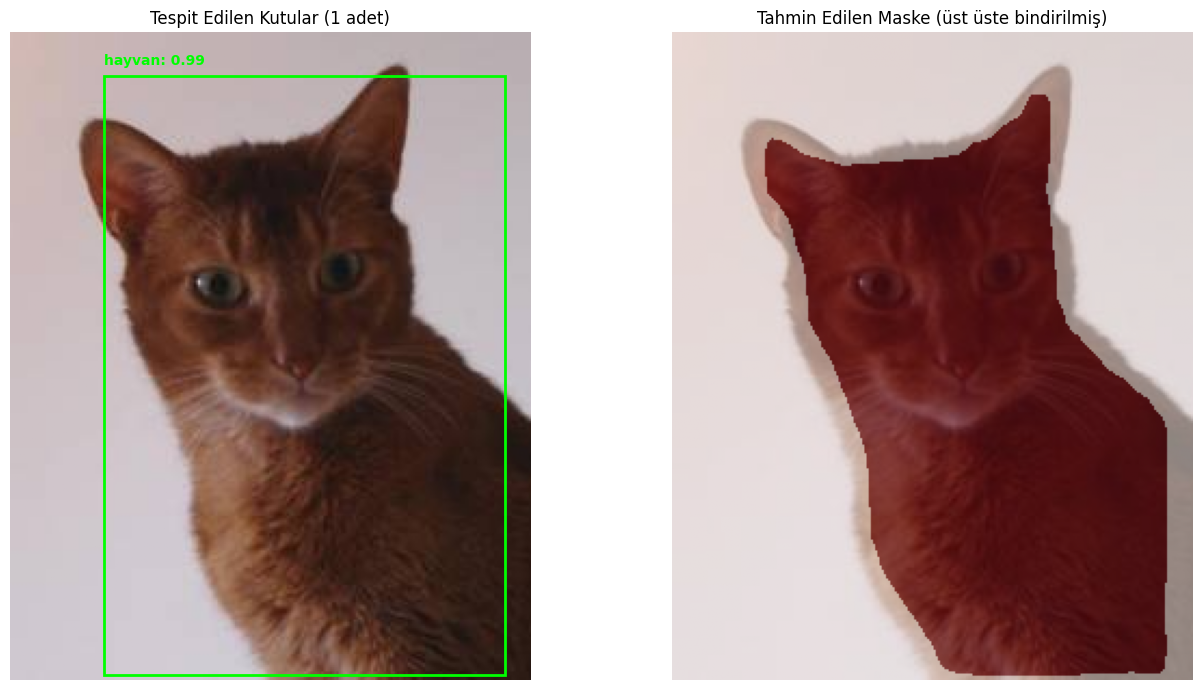

Toplam 1 nesne tespit edildi (eşik: 0.5)
  Nesne 1: güven skoru = 0.988


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

test_veri_ham = datasets.OxfordIIITPet(
    root="./data", split="test", target_types="segmentation", download=True,
)
test_dataset = PetDetectionDataset(test_veri_ham)

model_maskrcnn.eval()  # Değerlendirme moduna al

# Test setinden bir görüntü seçelim
img_tensor, gercek_hedef = test_dataset[7]

with torch.no_grad():
    tahmin = model_maskrcnn([img_tensor.to(device)])[0]

# Güven skoru 0.5'in üzerindeki tahminleri filtreleyelim
esik = 0.5
gecerli_idx = tahmin["scores"] > esik

kutular = tahmin["boxes"][gecerli_idx].cpu()
maskeler = tahmin["masks"][gecerli_idx].cpu()
skorlar = tahmin["scores"][gecerli_idx].cpu()

# --- Görselleştirme ---
img_np = img_tensor.permute(1, 2, 0).numpy()  # (C,H,W) -> (H,W,C)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Sol: orijinal görüntü + tahmin edilen kutular
ax1.imshow(img_np)
ax1.set_title(f"Tespit Edilen Kutular ({len(kutular)} adet)")
for kutu, skor in zip(kutular, skorlar):
    x1, y1, x2, y2 = kutu
    dikdortgen = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor="lime", facecolor="none"
    )
    ax1.add_patch(dikdortgen)
    ax1.text(x1, y1 - 5, f"hayvan: {skor:.2f}", color="lime", fontsize=10, weight="bold")
ax1.axis("off")

# Sağ: orijinal görüntü + tahmin edilen maske (varsa)
ax2.imshow(img_np)
if len(maskeler) > 0:
    birlesik_maske = maskeler[0, 0] > 0.5  # İlk (en yüksek skorlu) tahminin maskesi
    ax2.imshow(birlesik_maske, alpha=0.5, cmap="Reds")
ax2.set_title("Tahmin Edilen Maske (üst üste bindirilmiş)")
ax2.axis("off")

plt.tight_layout()
plt.show()

print(f"Toplam {len(kutular)} nesne tespit edildi (eşik: {esik})")
for i, skor in enumerate(skorlar):
    print(f"  Nesne {i+1}: güven skoru = {skor:.3f}")